# Decision Trees & Ensemble Methods — House Price Prediction

## Overview
In this notebook, we apply **Decision Trees**, **Random Forests**, and **Gradient Boosting** to predict house prices using the [House Prices dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) from Kaggle.

We cover:
- Decision Tree regression from scratch
- Random Forest and Gradient Boosting with scikit-learn
- Feature importance analysis
- Evaluation using RMSE and R²

## What are Decision Trees?
A Decision Tree recursively splits the data based on feature thresholds that minimize a cost function. For regression, we minimize **variance reduction**:

$$\text{Variance Reduction} = \text{Var}(y) - \left(\frac{n_L}{n}\text{Var}(y_L) + \frac{n_R}{n}\text{Var}(y_R)\right)$$

**Random Forests** build many trees on random subsets of data and features, averaging their predictions.  
**Gradient Boosting** builds trees sequentially, each correcting the errors of the previous.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')
%matplotlib inline

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('/Users/apple/Desktop/CMOR438/CMOR438-Spring2026/data/house_prices/train.csv')

features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
            'YearBuilt', 'YearRemodAdd']
target = 'SalePrice'

df_clean = df[features + [target]].dropna()

X = df_clean[features].values
y = df_clean[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1168, 10)
Test set size: (292, 10)


## 2. Decision Tree from Scratch

In [3]:
class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=5, min_samples_split=10):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return np.mean(y)
        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.mean(y)
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        return {
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }

    def _best_split(self, X, y):
        best_var_red, best_feature, best_threshold = 0, None, None
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue
                var_red = np.var(y) - (left_mask.sum() / len(y) * np.var(y[left_mask]) +
                                       right_mask.sum() / len(y) * np.var(y[right_mask]))
                if var_red > best_var_red:
                    best_var_red, best_feature, best_threshold = var_red, feature, threshold
        return best_feature, best_threshold

    def _predict_single(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node['feature']] <= node['threshold']:
            return self._predict_single(x, node['left'])
        return self._predict_single(x, node['right'])

    def predict(self, X):
        return np.array([self._predict_single(x, self.tree) for x in X])

# Train
model_scratch = DecisionTreeRegressorScratch(max_depth=5)
model_scratch.fit(X_train, y_train)

y_pred_scratch = model_scratch.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_scratch))
r2 = r2_score(y_test, y_pred_scratch)
print(f"Decision Tree Scratch — RMSE: {rmse:,.2f} | R²: {r2:.4f}")

Decision Tree Scratch — RMSE: 36,831.20 | R²: 0.8231


## 3. Decision Tree with Scikit-Learn

Decision Tree Sklearn — RMSE: 35,694.21 | R²: 0.8339


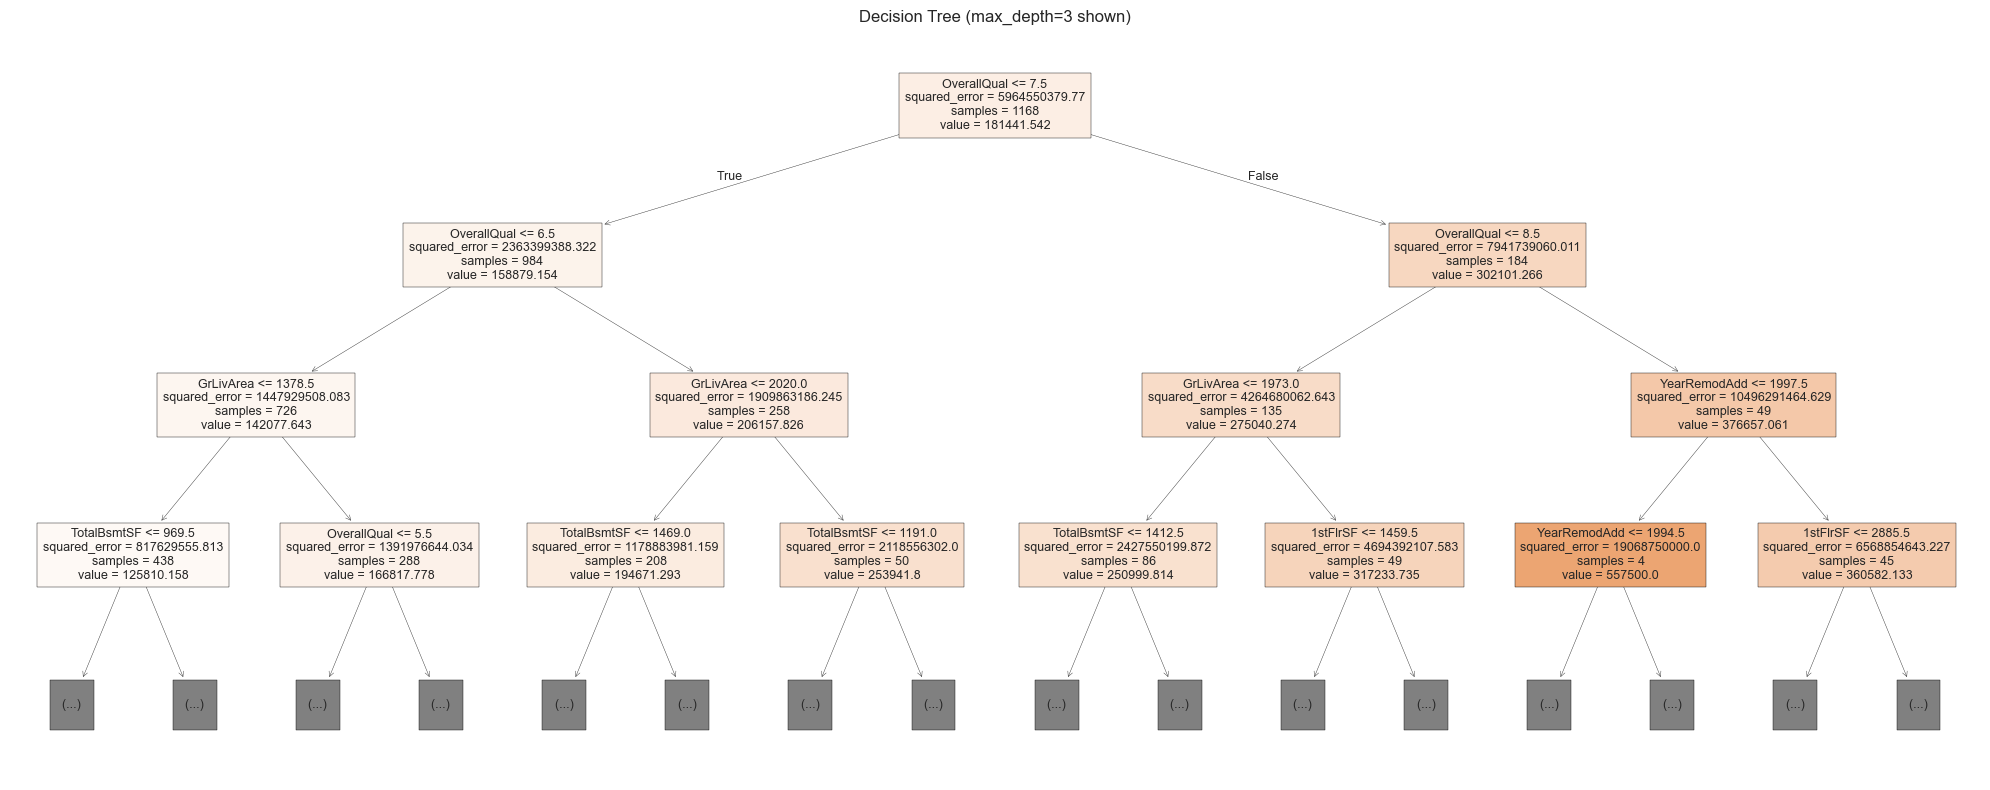

In [4]:
dt_sklearn = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_sklearn.fit(X_train, y_train)
y_pred_dt = dt_sklearn.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Decision Tree Sklearn — RMSE: {rmse_dt:,.2f} | R²: {r2_dt:.4f}")

# Visualize tree
plt.figure(figsize=(20, 8))
plot_tree(dt_sklearn, feature_names=features, filled=True, max_depth=3, fontsize=9)
plt.title('Decision Tree (max_depth=3 shown)')
plt.tight_layout()
plt.show()

## 4. Random Forest

In [5]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest — RMSE: {rmse_rf:,.2f} | R²: {r2_rf:.4f}")

Random Forest — RMSE: 29,619.24 | R²: 0.8856


## 5. Gradient Boosting

In [6]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting — RMSE: {rmse_gb:,.2f} | R²: {r2_gb:.4f}")

Gradient Boosting — RMSE: 29,575.84 | R²: 0.8860


## 6. Model Comparison & Feature Importance

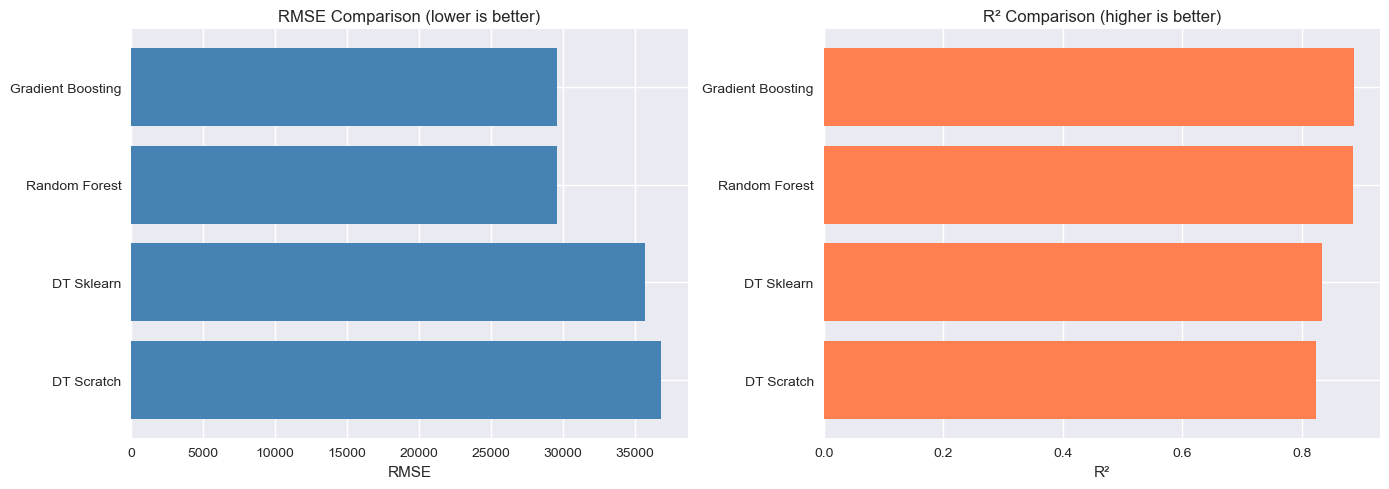

In [7]:
# Model comparison
models = ['DT Scratch', 'DT Sklearn', 'Random Forest', 'Gradient Boosting']
rmses = [rmse, rmse_dt, rmse_rf, rmse_gb]
r2s = [r2, r2_dt, r2_rf, r2_gb]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(models, rmses, color='steelblue')
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_xlabel('RMSE')

axes[1].barh(models, r2s, color='coral')
axes[1].set_title('R² Comparison (higher is better)')
axes[1].set_xlabel('R²')

plt.tight_layout()
plt.show()

/var/folders/_9/05gpf5dd4j70lgvrsl7wcwv80000gn/T/ipykernel_24706/3194553395.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='coolwarm')


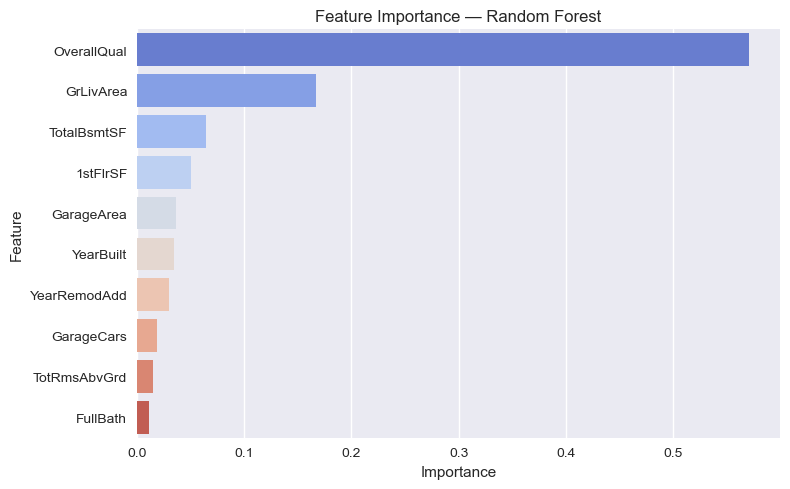

In [8]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='coolwarm')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

## 7. Conclusion

In this notebook, we compared Decision Trees, Random Forests, and Gradient Boosting for house price prediction.

Key takeaways:
- A single Decision Tree is interpretable but prone to overfitting.
- Random Forests reduce variance by averaging many trees, significantly improving performance.
- Gradient Boosting achieves the best results by sequentially correcting errors.
- **OverallQual** and **GrLivArea** consistently rank as the most important features across all models.